# Asesoría de Análisis de Datos: Web Scraping

**Objetivo:** Aprender de forma secuencial y práctica cómo extraer datos de la web, manipularlos y analizarlos con Pandas,todo dentro de un entorno de Google Colab/Jupyter Notebook.

**Temas:**
1. Web Scraping con `requests` y `BeautifulSoup`
2. Consumo de APIs con `requests` y Pandas


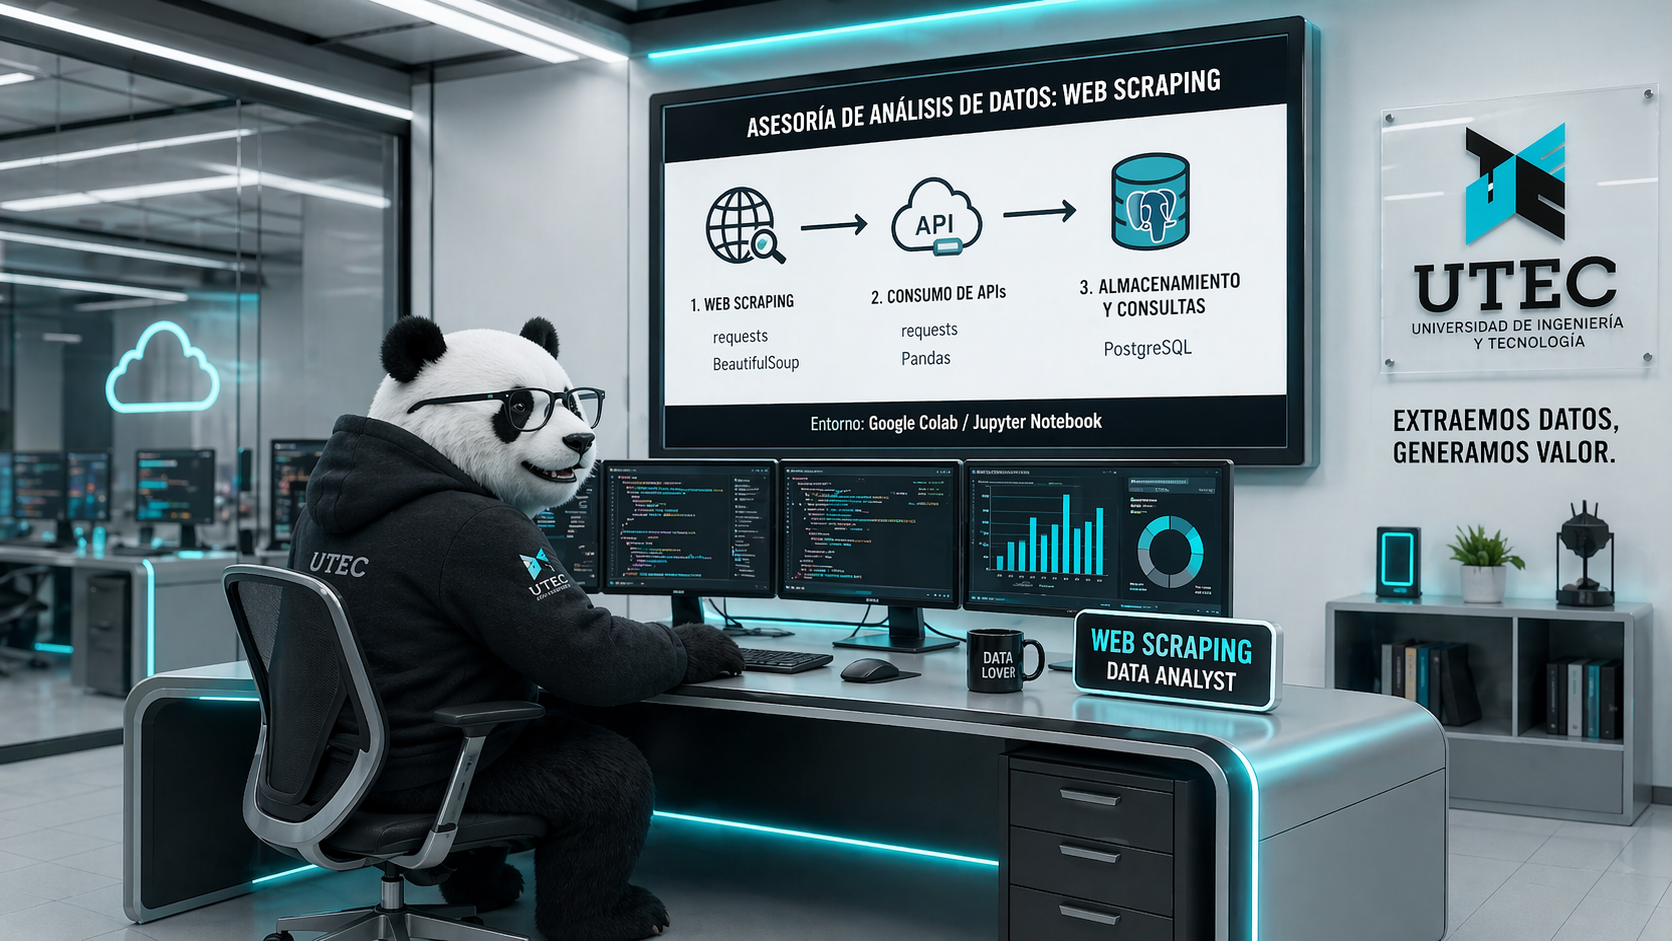

# 1. Webscrapping usando las APIS de la página web

In [5]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [1]:
# https://www.metro.pe/lacteos
# https://www.metro.pe/api/catalog_system/pub/products/search?fq=productId:1016033
# https://www.metro.pe/api/catalog_system/pub/products/search/lacteos


In [11]:
# Ejemplo con Cineplanet

# https://www.cineplanet.com.pe/api/cache/moviescache api de movies
# https://www.cineplanet.com.pe/api/cache/cinemascache api de cines
# https://resultadoelectoral.onpe.gob.pe/presentacion-backend/resumen-general/participantes?idEleccion=10&tipoFiltro=eleccion
import requests

movies_url = "https://www.cineplanet.com.pe/api/v1-web/cache/moviescache"

headers = {
       'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
   }

movies_response = requests.get(movies_url, headers=headers)

if movies_response.status_code == 200:
    data = movies_response.json()
else:
    print(f"Error fetching movies data: {movies_response.status_code}")

Error fetching movies data: 403


In [22]:
import requests

# Use a session to automatically handle cookies
session = requests.Session()

movies_url = "https://www.cineplanet.com.pe/api/v1-web/cache/moviescache"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'es-ES,es;q=0.9,en;q=0.8',
    'Origin': 'https://www.cineplanet.com.pe',
    'Referer': 'https://www.cineplanet.com.pe/',
    'Sec-Fetch-Dest': 'empty',
    'Sec-Fetch-Mode': 'cors',
    'Sec-Fetch-Site': 'same-origin',
}

# First, visit the main page to pick up any initial cookies
session.get("https://www.cineplanet.com.pe/", headers=headers)

# Now try the API call
response = session.get(movies_url, headers=headers)

if response.status_code == 200:
    print("Success!")
    data = response.json()
else:
    print(f"Still blocked: {response.status_code}")

Success!


In [12]:
data.keys()

dict_keys(['idMoviesBookingRestricted', 'movies'])

In [13]:
movies =data["movies"]
len(movies)

79

In [23]:
peli1 = movies[0]
peli1['genre']

'Thriller'

In [24]:
data["movies"][1]

{'id': 'HO00003109',
 'cast': {'cast': []},
 'director': 'null ',
 'formats': ['REGULAR', '2D'],
 'gallery': None,
 'isComingSoon': False,
 'OpeningDate': '2026-10-12T00:00:00-05:00',
 'restricted': True,
 'genre': 'Concierto',
 'genreId': '0000000012',
 'isNewRelease': False,
 'isPreSale': True,
 'isRePremiere': False,
 'isRemake': False,
 'festival': '',
 'languages': ['SUBTITULAD'],
 'posterUrl': 'https://cdn.apis.cineplanet.com.pe/CDN/media/entity/get/FilmPosterGraphic/HO00003109?referenceScheme=HeadOffice&allowPlaceHolder=true',
 'ratingDescription': '+14',
 'runTime': 100,
 'synopsis': 'Always Lalisa es un documental de larga duración que sigue a la superestrella mundial LISA durante un año transformador lejos de Blackpink, el fenómeno del K-pop que la convirtió en una de las artistas más reconocidas del mundo. Mientras el grupo se toma un descanso, LISA se lanza al primer capítulo de verdad de su carrera solista, enfrentándose a la pregunta de quién es ella más allá de Blackpink

In [26]:
# Quiero el director, formatos, si viene pronto, fecha de estreno, genero, duracion, synopsis, titulo, cinemas

movie_data = data["movies"][3]

director = movie_data.get('director')
formats = movie_data.get('formats')
is_coming_soon = movie_data.get('isComingSoon')
opening_date = movie_data.get('OpeningDate')
genre = movie_data.get('genre')
run_time = movie_data.get('runTime')
synopsis = movie_data.get('synopsis')
title = movie_data.get('title')
cinemas_data = movie_data.get('cinemas')

# Printing the extracted information
print(f"Título: {title}")
print(f"Director: {director}")
print(f"Formatos: {formats}")
print(f"¿Viene pronto?: {is_coming_soon}")
print(f"Fecha de estreno: {opening_date}") # de ahi parsearemos este opening date
print(f"Género: {genre}")
print(f"Duración: {run_time} minutos")
print(f"Sinopsis: {synopsis}")

Título: Album de Familia
Director: null 
Formatos: []
¿Viene pronto?: True
Fecha de estreno: 2026-09-17T00:00:00-05:00
Género: Drama
Duración: 94 minutos
Sinopsis: En un depósito, Alex descubre unas fotografías familiares que sugieren la participación de su padre en inquietantes eventos ocurridos en el país. A punto de convertirse él mismo en papá por primera vez, Alex se siente obligado a cuestionar sus lealtades familiares.


In [27]:
movies_formated = []

for i in range(len(data["movies"])):
    movie_data = data["movies"][i]
    director = movie_data.get('director')
    formats = movie_data.get('formats')
    is_coming_soon = movie_data.get('isComingSoon')
    opening_date = movie_data.get('OpeningDate')
    genre = movie_data.get('genre')
    run_time = movie_data.get('runTime')
    synopsis = movie_data.get('synopsis')
    title = movie_data.get('title')
    cinemas_data = movie_data.get('cinemas')

    # Agregamos la información parseada como un diccionario
    movies_formated.append({
        "Título": title,
        "Director": director,
        "Formatos": formats,
        "¿Viene pronto?": is_coming_soon,
        "Fecha de estreno": opening_date,
        "Género": genre,
        "Duración": run_time,
        "Sinopsis": synopsis
        #"Cines": cinemas_data
    })

movies_formated

[{'Título': 'A Cualquier Precio',
  'Director': 'null ',
  'Formatos': [],
  '¿Viene pronto?': True,
  'Fecha de estreno': '2026-09-17T00:00:00-05:00',
  'Género': 'Thriller',
  'Duración': 120,
  'Sinopsis': 'Un conocido asesino a sueldo de la mafia y un joven agente negro del FBI se unen para investigar los asesinatos de líderes de derechos civiles en Misisipi en 1966'},
 {'Título': 'ALWAYS LALISA',
  'Director': 'null ',
  'Formatos': ['REGULAR', '2D'],
  '¿Viene pronto?': False,
  'Fecha de estreno': '2026-10-12T00:00:00-05:00',
  'Género': 'Concierto',
  'Duración': 100,
  'Sinopsis': 'Always Lalisa es un documental de larga duración que sigue a la superestrella mundial LISA durante un año transformador lejos de Blackpink, el fenómeno del K-pop que la convirtió en una de las artistas más reconocidas del mundo. Mientras el grupo se toma un descanso, LISA se lanza al primer capítulo de verdad de su carrera solista, enfrentándose a la pregunta de quién es ella más allá de Blackpink.\

In [28]:
# Convertimos a dataframe
import pandas as pd

df_movies = pd.DataFrame(movies_formated)
df_movies.head(10)

,Título,Director,Formatos,¿Viene pronto?,Fecha de estreno,Género,Duración,Sinopsis
0,A Cualquier Precio,null,[],True,2026-09-17T00:00:00-05:00,Thriller,120,Un conocido asesino a sueldo de la mafia y un ...
1,ALWAYS LALISA,null,"[REGULAR, 2D]",False,2026-10-12T00:00:00-05:00,Concierto,100,Always Lalisa es un documental de larga duraci...
2,ANDRÉ RIEU 2026: LET IT SNOW CONCIERTO DE NAVIDAD,null,[],True,2026-12-05T00:00:00-05:00,Concierto,165,"Estas fiestas, celebra la época más maravillos..."
3,Album de Familia,null,[],True,2026-09-17T00:00:00-05:00,Drama,94,"En un depósito, Alex descubre unas fotografías..."
4,Angry Birds 3 La Pelicula,null,[],True,2026-12-23T00:00:00-05:00,Animación,120,"Esta temporada navideña, un pájaro enojado enf..."
5,Avengers Endgame Bonus,null,"[3D, REGULAR, PRIME, 2D]",False,2026-09-24T00:00:00-05:00,Acción,182,El épico final de la Saga del Infinito regresa...
6,Avengers Endgame Bonus Infinity Vision,null,"[3D, REGULAR, 2D, XTREME, IV]",False,2026-09-24T00:00:00-05:00,Acción,185,El épico final de la Saga del Infinito regresa...
7,Avengers: Doomsday,null,[],True,2026-12-17T00:00:00-05:00,Acción,166,"Avengers: Doomsday, los queridos héroes de tre..."
8,BTS WORLD TOUR 'ARIRANG' IN BUENOS AIRES: LIVE,null,[],True,2026-10-24T00:00:00-05:00,Concierto,195,BTS WORLD TOUR 'ARIRANG' IN BUENOS AIRES: LIVE...
9,BTS WORLD TOUR 'ARIRANG' IN SÃO PAULO: LIVE VIEW,null,[],True,2026-10-30T00:00:00-05:00,Concierto,195,BTS WORLD TOUR 'ARIRANG' IN SÃO PAULO: LIVE VI...


In [ ]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Título            67 non-null     object
 1   Director          67 non-null     object
 2   Formatos          67 non-null     object
 3   ¿Viene pronto?    67 non-null     bool  
 4   Fecha de estreno  67 non-null     object
 5   Género            67 non-null     object
 6   Duración          67 non-null     int64 
 7   Sinopsis          67 non-null     object
dtypes: bool(1), int64(1), object(6)
memory usage: 3.9+ KB


In [ ]:
df_movies.iloc[2]

,2
Título,Amando Amanda
Director,null
Formatos,[]
¿Viene pronto?,True
Fecha de estreno,2026-05-28T00:00:00-05:00
Género,Comedia
Duración,120
Sinopsis,-


In [ ]:
df_movies[["Título", "Género"]]

,Título,Género
0,911 Llamada Infernal,Thriller
1,Aida y vuelta,Comedia
2,Amando Amanda,Comedia
3,Amos del Universo,Acción
4,Backrooms,Terror
...,...,...
62,Toy Story 5,Animación
63,"Tu, yo y La Toscana",Comedia
64,Umamusume Pretty Derby,Anime
65,Volcan Fuego Bajo Tierra,Acción


In [ ]:
import requests

# Use a session to automatically handle cookies
session = requests.Session()

cinemas_url = "https://www.cineplanet.com.pe/api/v1-web/cache/cinemascache"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'es-ES,es;q=0.9,en;q=0.8',
    'Origin': 'https://www.cineplanet.com.pe',
    'Referer': 'https://www.cineplanet.com.pe/',
    'Sec-Fetch-Dest': 'empty',
    'Sec-Fetch-Mode': 'cors',
    'Sec-Fetch-Site': 'same-origin',
}

# First, visit the main page to pick up any initial cookies
session.get("https://www.cineplanet.com.pe/", headers=headers)

# Now try the API call
response = session.get(cinemas_url, headers=headers)

if response.status_code == 200:
    print("Success!")
    data_cines = response.json()
else:
    print(f"Still blocked: {response.status_code}")

Success!


In [ ]:
data_cines.keys()

dict_keys(['cinemas'])

In [ ]:
data_cines['cinemas'][0]

{'ID': '0000000001',
 'name': 'CP Alcazar',
 'phoneNumber': '016194400',
 'emailAddress': '',
 'address': 'Av. Santa Cruz 814-816',
 'secondAddress': 'Miraflores Lima Lima',
 'city': 'Lima',
 'latitude': '-12.1104',
 'longitude': '-77.0376',
 'description': 'CINEPLANET ALCAZAR',
 'showroomQuantity': 8,
 'formattedCinemaName': 'cp-alcazar',
 'services': [],
 'formatsRate': [],
 'formats': ['2D', 'REGULAR', '3D'],
 'img': 'https://cdnpe.cineplanet.com.pe/assets/77a68319-ab16-4888-b287-7a8235d6fb52',
 'loyaltyCode': '4',
 'showTabsPrime': True,
 'type': 'regular'}

# 2. Web Scraping con `requests` y `BeautifulSoup`

El web scraping es la técnica de extraer información de sitios web de forma automatizada. Usaremos la librería `requests` para obtener el contenido HTML de una página y `BeautifulSoup` para parsearlo y navegar por su estructura.

### 1.1. Conceptos Básicos de HTML

HTML (HyperText Markup Language) es el lenguaje estándar para crear páginas web. Los documentos HTML están compuestos por **elementos** o **etiquetas** que estructuran el contenido.

- **Etiquetas (Tags):** Definen la estructura y semántica del contenido (ej: `<p>` para párrafo, `<a>` para enlace, `<table>` para tabla, `<h1>` para encabezado principal).
- **Atributos:** Proveen información adicional sobre los elementos (ej: `<a href="url">` donde `href` es un atributo que indica el destino del enlace; `<img src="imagen.jpg" alt="descripción">`).
- **Clases (class) e IDs (id):** Atributos especiales usados para identificar y estilizar elementos. Las clases pueden ser compartidas por múltiples elementos, mientras que un ID debe ser único en la página.

### 1.2. Instalación de Librerías

Si estás en Google Colab, `requests` y `beautifulsoup4` generalmente ya vienen instalados. Si ejecutas esto localmente y no las tienes, puedes instalarlas con pip:

```bash
pip install requests beautifulsoup4
```

In [ ]:
# Importamos las librerías necesarias
import requests
from bs4 import BeautifulSoup
import pandas as pd # Lo usaremos más adelante para convertir los datos scrapeados

### 1.3. Realizar una Petición HTTP con `requests`

Usamos `requests.get(url)` para solicitar el contenido de una página web. El servidor web devuelve una respuesta, y si la solicitud es exitosa (código de estado 200), podemos acceder al contenido HTML.

In [ ]:
# URL de ejemplo para scrapear
url_ejemplo_scraping = 'https://es.wikipedia.org/wiki/Anexo:Pa%C3%ADses_y_territorios_dependientes_por_densidad_de_poblaci%C3%B3n'

# Definimos un User-Agent para simular un navegador
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
# Usamos un user-agent para que wikipedia no nos bloquee el request

# Realizamos la petición GET incluyendo los headers
response = requests.get(url_ejemplo_scraping, headers=headers)

# Verificamos el código de estado (200 significa OK)
print(f"Código de estado: {response.status_code}")

Código de estado: 200


In [ ]:
# Obtenemos el contenido HTML si la solicitud fue exitosa
html_content = None
if response.status_code == 200:
    html_content = response.content
    print("Contenido obtenido exitosamente.")
else:
    print(f"Error al obtener la página: {response.status_code}")

Contenido obtenido exitosamente.


### 1.4. Parsear el Contenido HTML con `BeautifulSoup`

Una vez que tenemos el HTML, creamos un objeto `BeautifulSoup` para interpretarlo y poder navegar por él.

In [ ]:
if html_content:
    # Creamos el objeto BeautifulSoup
    # 'html.parser' es un parser común, pero puedes usar 'lxml' si lo tienes instalado (suele ser más rápido)
    soup = BeautifulSoup(html_content, 'html.parser')
    print("Objeto BeautifulSoup creado.")
else:
    soup = None
    print("No hay contenido HTML para parsear.")

Objeto BeautifulSoup creado.


In [ ]:
soup = BeautifulSoup(html_content, 'html.parser')
soup.prettify()

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="es">\n <head>\n  <meta charset="utf-8"/>\n  <title>\n   Anexo:Países y territorios dependientes por densidad de población - Wikipedia, la enciclopedia libre\n  </title>\n  <script>\n   (function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-too

### 1.5. Encontrar Elementos HTML

BeautifulSoup ofrece varios métodos para encontrar elementos:

- `soup.find('tag_name')`: Encuentra la primera ocurrencia de una etiqueta.
- `soup.find_all('tag_name')`: Encuentra todas las ocurrencias de una etiqueta y las devuelve como una lista.
- `soup.find(id='element_id')`: Encuentra un elemento por su `id`.
- `soup.find_all(class_='class_name')`: Encuentra todos los elementos con una clase CSS específica (nota el guion bajo en `class_`).
- `soup.select('css_selector')`: Permite usar selectores CSS más complejos (ej: `soup.select('table.wikitable > tbody > tr')`).

#### Ejemplo: Encontrar el título de la página

In [ ]:
if soup:
    # Encontrar la etiqueta <title>
    page_title_tag = soup.find('title')
    if page_title_tag:
        page_title = page_title_tag.get_text()
        print(f"Título de la página: {page_title}")
    else:
        print("No se encontró la etiqueta <title>.")

Título de la página: Anexo:Países y territorios dependientes por densidad de población - Wikipedia, la enciclopedia libre


In [ ]:
if soup:
    # Encontrar la etiqueta <title>
    page_title_tags = soup.find_all('title')
    if page_title_tags:
        for page_title_tag in page_title_tags:
            page_title = page_title_tag.get_text()
            print(f"Título de la página: {page_title}")
    else:
        print("No se encontró la etiqueta <title>.")

Título de la página: Anexo:Países y territorios dependientes por densidad de población - Wikipedia, la enciclopedia libre


In [ ]:
tabla = soup.find('table', class_='wikitable')
tabla

<table class="wikitable sortable" id="mwEg" style="text-align: right">
<tbody id="mwEw"><tr id="mwFA"><th id="mwFQ">Pos.</th><th id="mwFg">País (o territorio dependiente)</th><th id="mwFw">Superficie<br id="mwGA"/>o área<br id="mwGQ"/>(<a href="//es.wikipedia.org/wiki/Kilómetro_cuadrado" id="mwGg" rel="mw:WikiLink" title="Kilómetro cuadrado">km<span id="mwGw" typeof="mw:Entity">²</span></a>)</th><th id="mwHA">Proyección<br id="mwHQ"/>de la<br id="mwHg"/>población<br id="mwHw"/>al<br id="mwIA"/>1/7/2025</th><th id="mwIQ">Densidad<br id="mwIg"/>de<br id="mwIw"/>población<br id="mwJA"/>(Hab./km<span id="mwJQ" typeof="mw:Entity">²</span>)</th><th id="mwJg">Censo más<br id="mwJw"/>reciente,<br id="mwKA"/>última,<br id="mwKQ"/>estimación<br id="mwKg"/>oficial o<br id="mwKw"/>proyección<br id="mwLA"/>de la <a href="//es.wikipedia.org/wiki/Organización_de_las_Naciones_Unidas" id="mwLQ" rel="mw:WikiLink" title="Organización de las Naciones Unidas">ONU</a><br id="mwLg"/>reloj de<br id="mwLw"/>po

In [ ]:
import pandas as pd

# Usamos pd.read_html para convertir el objeto soup de la tabla directamente a una lista de DataFrames
# [0] selecciona el primer DataFrame de esa lista
df_table = pd.read_html(str(tabla))[0]

# Mostramos los primeros resultados
df_table.head()

/tmp/ipykernel_1532/2973295244.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_table = pd.read_html(str(tabla))[0]


,Pos.,País (o territorio dependiente),Superficie o área (km²),Proyección de la población al 1/7/2025,Densidad de población (Hab./km²),"Censo más reciente, última, estimación oficial o proyección de la ONU reloj de población nacional",Densidad de población (Hab./km²).1,Fecha de esta última cifra de población en particular (d/mm/aaaa),Tipo[1]
0,1,Macao (China)[2],30,688 000,22 706,687 900,22 930,31/03/2025,T
1,2,Mónaco,2,39 000,19 500,38 857,19 429,31/12/2025,E
2,3,Singapur[3],704,6 110 000,8 679,6 110 200,8 679,30/06/2025,E
3,4,Hong Kong (China)[4],1 083,7 506 000,6 933,7 510 800,6 935,31/12/2025,B
4,5,Gibraltar (RU)[5],6,40 000,6 667,38 196,6 366,14/11/2022,C


### 1.5.1 Ejemplo con productos de sodimac

In [ ]:
!pip install cloudscraper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 1.3 MB/s eta 0:00:00


In [ ]:
import cloudscraper

scraper = cloudscraper.create_scraper() # Instancia un scraper que evade bloqueos
url = "https://www.sodimac.com.pe/sodimac-pe/lista/cat40584/Electrohogar?page=1&store=so_com"

response = scraper.get(url)
print(response.status_code)

403


In [15]:
import requests

url = "https://www.sodimac.com.pe/sodimac-pe/lista/cat40584/Electrohogar"

# Simulamos ser Google Chrome en Windows
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "es-PE,es;q=0.9,en-US;q=0.8,en;q=0.7",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8"
}

# Ejemplo para recorrer las primeras 3 páginas
for i in range(1, 4):
    page_url = f"{url}?page={i}&store=so_com"
    response = requests.get(page_url, headers=headers)

    print(f"Página {i}: Respuesta {response.status_code}")

    # Si la respuesta es 200, ya puedes procesar el HTML
    if response.status_code == 200:
        # html = response.text
        pass

Página 1: Respuesta 403
Página 2: Respuesta 403
Página 3: Respuesta 403


In [17]:
url = "https://www.sodimac.com.pe/sodimac-pe/lista/cat40584/Electrohogar"

page = requests.get(url)
page

<Response [403]>

In [ ]:
soup = BeautifulSoup(page.content, "html.parser")
soup.prettify()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
gallery = soup.find(id="testId-searchResults-products")
gallery

<div class="jsx-2993599420 search-results--products" id="testId-searchResults-products"><div class="jsx-160183156 search-results-4-grid grid-pod" data-testid="ssr-pod" pod-highlight="false" pod-layout="4_GRID"><a class="jsx-848928493 jsx-1602525824 pod pod-4_GRID pod-link" data-gsccategory="G14030304" data-key="151210544" data-pod="catalyst-pod" data-sponsored="true" href="" id="testId-pod-151210545" role="button" tabindex="0"><div class="jsx-848928493 jsx-1602525824 pod-head"><div class="jsx-2167806851"><section class="jsx-2167806851 layout_grid-view layout_view_4_GRID"><picture class="jsx-1996933093"><source class="jsx-1996933093" srcset="https://media.sodimac.com.pe/falabellaPE/151210545_01/width=240,height=240,quality=70,format=webp,fit=pad, https://media.sodimac.com.pe/falabellaPE/151210545_01/width=480,height=480,quality=70,format=webp,fit=pad 2x" type="image/webp,image/*,*/*"/><img alt="DREAME - Dreame Aspiradora en Seco Y HÃºmedo H12 Pro Flexreach Alcance plano de 180Â° 90Â°C L

Obtenemos el elemento que contenga los productos solamente

In [18]:
items = gallery.find_all("div", class_="jsx-160183156")
items[0]
# Veremos la logica para sacar la info de un item, luego lo aplicaremos con los demás

NameError: name 'gallery' is not defined

In [ ]:
# Queremos la marca, el nombre del producto y quien es el proveedor
marca = items[0].find("b") # items[0].find_all("b")[0]
marca.text

<b class="jsx-3474284645 title1 secondary jsx-233704000 bold pod-title title-rebrand">SAMSUNG</b>

In [ ]:
# Pero si usamos find all?
info = items[0].find_all("b")
info

[<b class="jsx-3474284645 title1 secondary jsx-233704000 bold pod-title title-rebrand">SAMSUNG</b>,
 <b class="jsx-3474284645 copy2 primary jsx-233704000 normal line-clamp line-clamp-3 pod-subTitle subTitle-rebrand" id="testId-pod-displaySubTitle-130775616">Lavadora WA13CG5441BVPE 13 Kg</b>,
 <b class="jsx-3474284645 copy2 primary jsx-233704000 normal pod-sellerText seller-text-rebrand" id="testId-pod-displaySellerText-130775616">Por SODIMAC</b>]

In [ ]:
marca = info[0].get_text()
nombre = info[1].get_text()
proveedor = info[2].get_text()
print(f"Marca: {marca}, Nombre: {nombre}, Proveedor: {proveedor}")

Marca: SAMSUNG, Nombre: Lavadora WA13CG5441BVPE 13 Kg, Proveedor: Por SODIMAC


Ahora queremos el precio


In [ ]:
# Ahora queremos el precio
precios = items[0].find_all("span")
precios

[<span class="jsx-3425244783 jsx-11683791 pod-badges-item-4_GRID pod-badges-item event-sticker-bold" id="testId-Pod-badges-event" style="background-color:#0433ff;color:#ffffff">CYBER WOW</span>,
 <span style="overflow:hidden"><b class="jsx-3474284645 copy2 primary jsx-233704000 normal pod-sellerText seller-text-rebrand" id="testId-pod-displaySellerText-130775616">Por SODIMAC</b><span class="jsx-3474284645 sodimacIcon seller-icon" id="seller-icon"></span></span>,
 <span class="jsx-3474284645 sodimacIcon seller-icon" id="seller-icon"></span>,
 <span class="copy10 primary medium jsx-233704000 normal line-height-22" id="">S/  899.90  </span>,
 <span class="jsx-3475638340 copy5 primary jsx-233704000 bold discount-badge-item" id="testId-Pod-badges--40%" style="background-color:#EB0029;color:#ffffff">-40%</span>,
 <span class="copy3 primary medium jsx-233704000 normal crossed line-height-17" id="">S/  1,499.90  </span>,
 <span class="jsx-3425244783 jsx-11683791 pod-badges-item-4_GRID pod-badg

In [ ]:
len(precios)

10

In [ ]:
for i in range(len(precios)):
    print(precios[i].get_text())

CYBER WOW
Por SODIMAC

S/  899.90  
-40%
S/  1,499.90  
Retira maÃ±ana


(68)


In [ ]:
Por Sodimac [0] --> proveedor (no lo quiero)
            [1]    --> vacio (no lo quiero)
S/  1,099.90  [2]    --> oferta
-12%          [3]    --> descuento
S/  1,249.90  [4]    --> precio og
Envío gratis

In [ ]:
precios = items[2].find_all("span")
for i in range(len(precios)):
    print(precios[i].get_text())

# Vemos que no sigue un mismo orden

CYBER WOW
Por SODIMAC

S/  899.90  
-40%
S/  1,499.90  
Retira maÃ±ana


(70)


Usaremos otro tipo de lógica (intento buscando un orden en la lista de elementos acotando)

In [ ]:
#jsx-3844086616

precio_box = items[0].find("ol", class_="jsx-3493300662")
precio_box

<ol class="jsx-3493300662 ol-4_GRID pod-prices fa--prices li-separation"><li class="jsx-3493300662 prices-0" data-internet-price="899.90"><div class="jsx-3493300662 cmr-icon-container" data-variant="DESKTOP_4_GRID"><span class="copy10 primary medium jsx-233704000 normal line-height-22" id="">S/  899.90  </span> <div class="jsx-3475638340 discount-badge"><span class="jsx-3475638340 copy5 primary jsx-233704000 bold discount-badge-item" id="testId-Pod-badges--40%" style="background-color:#EB0029;color:#ffffff">-40%</span></div><div class="jsx-3493300662 price-extras"></div></div></li><li class="jsx-3493300662 prices-1" data-normal-price="1,499.90"><div class="jsx-3493300662 cmr-icon-container" data-variant="DESKTOP_4_GRID"><span class="copy3 primary medium jsx-233704000 normal crossed line-height-17" id="">S/  1,499.90  </span> <div class="jsx-3493300662 price-extras"></div></div></li></ol>

Usaremos otro tipo de lógica (lógica final usando etiquetas fijas)

- Tenemos que los elementos li "data cmr price" y "data event price" corresponden a productos con ofertas

- Adicionalmente siempre se tiene el li "data internet price" que es el precio sin descuento

In [ ]:
internet_price = precio_box.find("li", attrs={"data-internet-price": True})
internet_price.get_text()

'S/  899.90   -40%'

In [ ]:
# Tenemos la logica para uno de los items, toca aplicarlo con todos los items y almacenarlo todo

productos = []

for item in items:
  #####
    try:
        # Obtener marca, nombre y proveedor
        info = item.find_all("b")
        marca = info[0].get_text() if len(info) > 0 else "N/A"
        nombre = info[1].get_text() if len(info) > 1 else "N/A"
        proveedor = info[2].get_text() if len(info) > 2 else "N/A"

        # Precio original
        price_og_li = item.find("li", attrs={"data-internet-price": True})
        precio_original = price_og_li.get_text().strip() if price_og_li else "N/A"

        # Precio de oferta (puede ser cmr o event)
        oferta_box = item.find("li", attrs={"data-cmr-price": True})
        if not oferta_box:
            oferta_box = item.find("li", attrs={"data-event-price": True})

        precio_oferta = "N/A"
        descuento = "N/A"
        if oferta_box:
            precio_span = oferta_box.find("span", class_="copy10")
            if precio_span:
                precio_oferta = precio_span.get_text().strip()
            descuento_div = oferta_box.find("div", class_="jsx-2855665538 discount-badge")
            if descuento_div:
                descuento = descuento_div.get_text().strip()

        productos.append({
            "marca": marca,
            "nombre": nombre,
            "proveedor": proveedor,
            "precio_original": precio_original,
            "precio_oferta": precio_oferta,
            "descuento": descuento
        })
  ####

    except Exception as e:
        print(f"Error procesando un item: {e}")

In [ ]:
# Visualizamos
for prod in productos:
    print(prod)

{'marca': 'SAMSUNG', 'nombre': 'Lavadora WA13CG5441BVPE 13 Kg', 'proveedor': 'Por SODIMAC', 'precio_original': 'S/  899.90   -40%', 'precio_oferta': 'N/A', 'descuento': 'N/A'}
{'marca': 'ELECTROLUX', 'nombre': 'Refrigeradora 419L Top Freezer Side By Side 2 Puertas ERS45F2P5EB', 'proveedor': 'Por SODIMAC', 'precio_original': 'S/  1,599.90', 'precio_oferta': 'S/  1,499.90', 'descuento': 'N/A'}
{'marca': 'SAMSUNG', 'nombre': 'Lavadora WA13CG5441BVPE 13 Kg', 'proveedor': 'Por SODIMAC', 'precio_original': 'S/  899.90   -40%', 'precio_oferta': 'N/A', 'descuento': 'N/A'}
{'marca': 'ELECTROLUX', 'nombre': 'Refrigeradora 419L Top Freezer Side By Side 2 Puertas ERS45F2P5EB', 'proveedor': 'Por SODIMAC', 'precio_original': 'S/  1,599.90', 'precio_oferta': 'S/  1,499.90', 'descuento': 'N/A'}
{'marca': 'NINJA', 'nombre': 'Licuadora Profesional 2L 1400W BN701CL.', 'proveedor': 'Por SODIMAC', 'precio_original': 'S/  329', 'precio_oferta': 'S/  279.90', 'descuento': 'N/A'}
{'marca': 'ELECTROLUX', 'nomb

In [ ]:
import pandas as pd

tabla = pd.DataFrame(productos)
tabla

,marca,nombre,proveedor,precio_original,precio_oferta,descuento
0,SAMSUNG,Lavadora WA13CG5441BVPE 13 Kg,Por SODIMAC,S/ 899.90 -40%,N/A,N/A
1,ELECTROLUX,Refrigeradora 419L Top Freezer Side By Side 2 ...,Por SODIMAC,"S/ 1,599.90","S/ 1,499.90",N/A
2,SAMSUNG,Lavadora WA13CG5441BVPE 13 Kg,Por SODIMAC,S/ 899.90 -40%,N/A,N/A
3,ELECTROLUX,Refrigeradora 419L Top Freezer Side By Side 2 ...,Por SODIMAC,"S/ 1,599.90","S/ 1,499.90",N/A
4,NINJA,Licuadora Profesional 2L 1400W BN701CL.,Por SODIMAC,S/ 329,S/ 279.90,N/A
5,ELECTROLUX,Horno Microondas 20L EMDO20S2GSRUG,Por SODIMAC,S/ 249.90,S/ 229.90,N/A
6,LG,Refrigeradora VT24BPY 241L Plateado,Por SODIMAC,S/ 899.90,S/ 849.90,N/A
7,DREAME,Aspiradora en Seco Y HÃºmedo H12 Pro Flexreach...,Por Tienda Oficial Dreame PerÃº,N/A,"S/ 1,599",N/A
8,OSTER,Licuadora 1.5L 550W 2 velocidades BLSTKAG-KPB ...,Por SODIMAC,S/ 169.90,S/ 159.90,N/A
9,OSTER,Plancha 2140153 Azul.,Por SODIMAC,S/ 79.90,S/ 69.90,N/A


### 1.5.2 Ejemplo: Que pasa con las páginas que se cargan de manera dinámica?

In [ ]:
url = "https://www.metro.pe/electrohogar/lavado-y-secado"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

page = requests.get(url, headers=headers)
page

<Response [200]>

In [ ]:
soup = BeautifulSoup(page.content, "html.parser")
soup.prettify()

'<!DOCTYPE html>\n<html lang="es-PE">\n <head>\n  <meta content="width=device-width, initial-scale=1" name="viewport"/>\n  <meta content="vtex.render-server@8.178.1" name="generator"/>\n  <meta charset="utf-8"/>\n  <style id="critical" type="text/css">\n   @charset "UTF-8";html{line-height:1.15;-ms-text-size-adjust:100%;-webkit-text-size-adjust:100%}body{margin:0}nav,section{display:block}a{background-color:transparent;-webkit-text-decoration-skip:objects}img{border-style:none}svg:not(:root){overflow:hidden}button,input{font-family:sans-serif;font-size:100%;line-height:1.15;margin:0}button,input{overflow:visible}button{text-transform:none}button{-webkit-appearance:button}button::-moz-focus-inner{border-style:none;padding:0}button:-moz-focusring{outline:1px dotted ButtonText}::-webkit-file-upload-button{-webkit-appearance:button;font:inherit}.bg-light-gray{background-color:#e3e4e6}.bg-red{background-color:#ff4c4c}.bg-base{background-color:#fff}.bg-transparent{background-color:transparen

In [ ]:
dataContent = soup.find("div", class_="vtex-search-result-3-x-gallery")
dataContent

<div class="vtex-search-result-3-x-gallery vtex-search-result-3-x-gallery--product-summary-plp vtex-search-result-3-x-gallery--whole vtex-search-result-3-x-gallery--product-summary-plp--whole flex flex-row flex-wrap items-stretch bn ph1 na4 pl9-l" id="gallery-layout-container"></div>

In [ ]:
dataContent = soup.find(id="gallery-layout-container")
dataContent

<div class="vtex-search-result-3-x-gallery vtex-search-result-3-x-gallery--product-summary-plp vtex-search-result-3-x-gallery--whole vtex-search-result-3-x-gallery--product-summary-plp--whole flex flex-row flex-wrap items-stretch bn ph1 na4 pl9-l" id="gallery-layout-container"></div>

In [ ]:
products = dataContent.find_all("div")
products

[]